<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
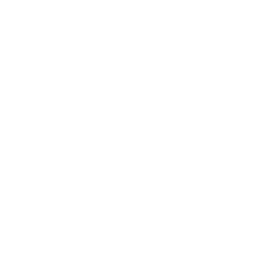
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interval-Censored Joint Replacement Revision Risk</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Orthopedic Surgery Outcomes &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Podsumowanie wykonawcze

Coroczny nadzór radiograficzny wykrywa niepowodzenie protezy tylko między wizytami, więc każdy czas do rewizji jest **ucięty przedziałowo**: wiadomo tylko, że mieści się między ostatnią czystą wizytą a pierwszą wizytą, przy której wskazana jest rewizja. Niniejsze badanie dopasowuje model proporcjonalnych hazardów za pomocą `PROC ICPHREG` do rejestru 100 wymian stawu biodrowego i kolanowego oraz oszacowuje, jak materiał powierzchni łożyska protezy, BMI pacjenta, staw i podejście chirurgiczne wpływają na hazard rewizji.

Dopasowany model wskazuje powierzchnię łożyska i BMI jako dominujące czynniki ryzyka. Względem referencyjnej ceramiki-ceramiki, implanty metal-polietylen niosą **3,29-krotny hazard rewizji** (95% CI 1,76-6,16, p=0,0002), a każda dodatkowa jednostka BMI zwiększa hazard o **11%** (HR 1,11, 95% CI 1,05-1,18, p=0,0005). Wymiany stawu kolanowego wykazują tendencję do wyższego ryzyka rewizji niż biodra (HR 1,55, p=0,057). Wiek, płeć i podejście chirurgiczne nie wykazują istotnego związku. Wyniki te przemawiają za preferowaniem łożysk ceramicznych oraz optymalizacją masy ciała u pacjentów o podwyższonym ryzyku zużycia.

## Źródła danych

| Zbiór danych | N | Opis |
|---------|---|-------------|
| joint_registry | 100 | Symulowany rejestr wymian stawów z coroczną obserwacją; czas do rewizji każdego implantu jest ucięty przedziałowo między ostatnią czystą wizytą (`last_ok_years`) a pierwszą wizytą wskazującą rewizję (`first_revision_years`). |

Kohorta jest generowana ze znanym mechanizmem generującym dane, dzięki czemu odtworzone przez model hazard ratio można porównać z zaplanowanymi efektami. Utajony czas do rewizji jest losowany z rozkładu wykładniczego, którego intensywność rośnie wraz z łożyskami metal-polietylen, wyższym BMI i stawami kolanowymi, a następnie jest zaokrąglany do siatki corocznych wizyt, aby uzyskać rzeczywiste ucięcie przedziałowe.

---

In [1]:
/* Rejestr wymian stawów z coroczną kontrolą.
   Każdy implant jest badany raz w roku; rewizję obserwuje się tylko
   jako mieszczącą się między ostatnią czystą wizytą a pierwszą wizytą
   ze wskazaniem do rewizji, co daje czas do rewizji ucięty przedziałowo.
   Znany mechanizm generujący pozwala zweryfikować odtworzone hazard ratio. */
DANE joint_registry;
    CALL streaminit(20260311);
    TABLICA materials[3] $10 ('CeramCeram' 'CeramPoly' 'MetalPoly');
    TABLICA approaches[2] $10 ('Anterior' 'Posterior');
    max_followup = 12;            /* 12 corocznych wizyt kontrolnych */
    POWTÓRZ patient_id = 1 TO 100;
        joint      = ifc(rand('uniform') < 0.5, 'Hip', 'Knee');
        prosthesis = materials[ rand('integer', 1, 3) ];
        approach   = approaches[ rand('integer', 1, 2) ];
        age_surgery = round(60 + rand('normal') * 9);
        bmi         = round(28 + rand('normal') * 4, 0.1);
        female      = (rand('uniform') < 0.55);

        /* Log-hazard: zużycie metal-polietylen jest najgorsze, ceramika-ceramika
           najlepsza; otyłość oraz młodsi, bardziej aktywni pacjenci zwiększają ryzyko. */
        eta = 0.85 * (prosthesis = 'MetalPoly')
            + 0.40 * (prosthesis = 'CeramPoly')
            + 0.06 * (bmi - 28)
            - 0.02 * (age_surgery - 60)
            + 0.30 * (joint = 'Knee');

        /* Utajony czas do rewizji ~ Wykładniczy(rate = exp(eta)/8). */
        rate   = EXP(eta) / 8;
        latent = -LOG(rand('uniform')) / rate;

        /* Zaokrąglenie do siatki corocznych wizyt: znamy tylko wizyty
           graniczne (ostatnia czysta, pierwsza nieudana). */
        JEŚLI latent > max_followup WTEDY POWTÓRZ;
            last_ok_years        = max_followup;   /* OK przy ostatniej wizycie */
            first_revision_years = .;              /* ucięcie prawostronne  */
            revised = 0;
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            last_ok_years        = floor(latent);  /* ostatnia czysta wizyta */
            first_revision_years = ceil(latent);   /* pierwsza wizyta ze wskazaniem */
            JEŚLI first_revision_years = last_ok_years WTEDY
                first_revision_years = last_ok_years + 1;
            JEŚLI last_ok_years = 0 WTEDY last_ok_years = .;  /* ucięcie lewostronne */
            revised = 1;
        KONIEC;
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ patient_id joint prosthesis approach age_surgery bmi female
         last_ok_years first_revision_years revised;
WYKONAJ;


NOTE: DATA joint_registry


NOTE: Wrote joint_registry (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of Staw by Powierzchnia łożyska protezy

Staw |CeramCeram | CeramPoly | MetalPoly |      Total
-----+-----------+-----------+-----------+-----------
Hip  |        13 |        19 |        13 |         45
-----+-----------+-----------+-----------+-----------
Knee |        11 |        27 |        17 |         55
-----+-----------+-----------+-----------+-----------
Total |        24 |        46 |        30 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_joint_prosthesis.spec.json
NOTE: PROC FREQ statement used.


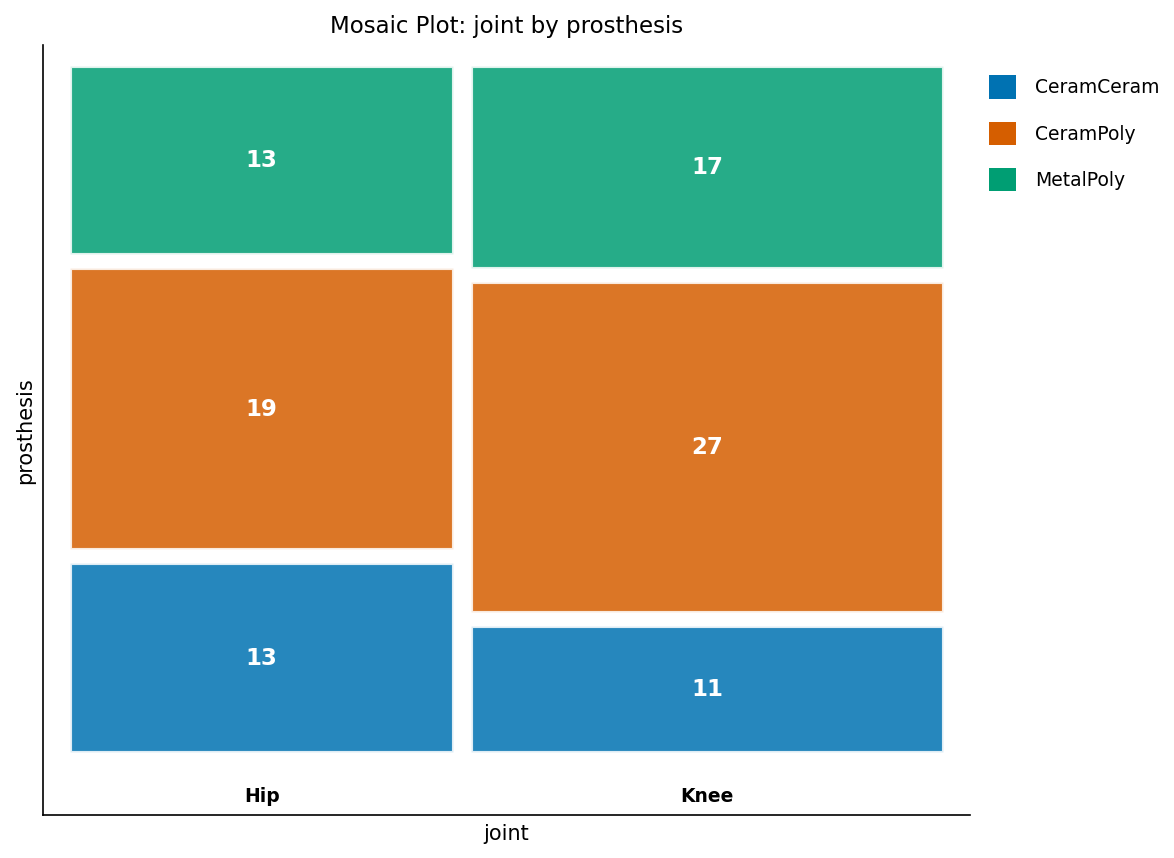

In [2]:
/* Skład próby: powierzchnia łożyska według stawu */
PROCEDURA CZĘSTOŚCI DANE=joint_registry;
    TABLES joint * prosthesis / nocum nopercent;
    ETYKIETA joint='Staw' prosthesis='Powierzchnia łożyska protezy';
WYKONAJ;

---


NOTE: DATA revised_only


NOTE: Read 100 rows from joint_registry.
NOTE: Wrote revised_only (90 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=revised_only

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


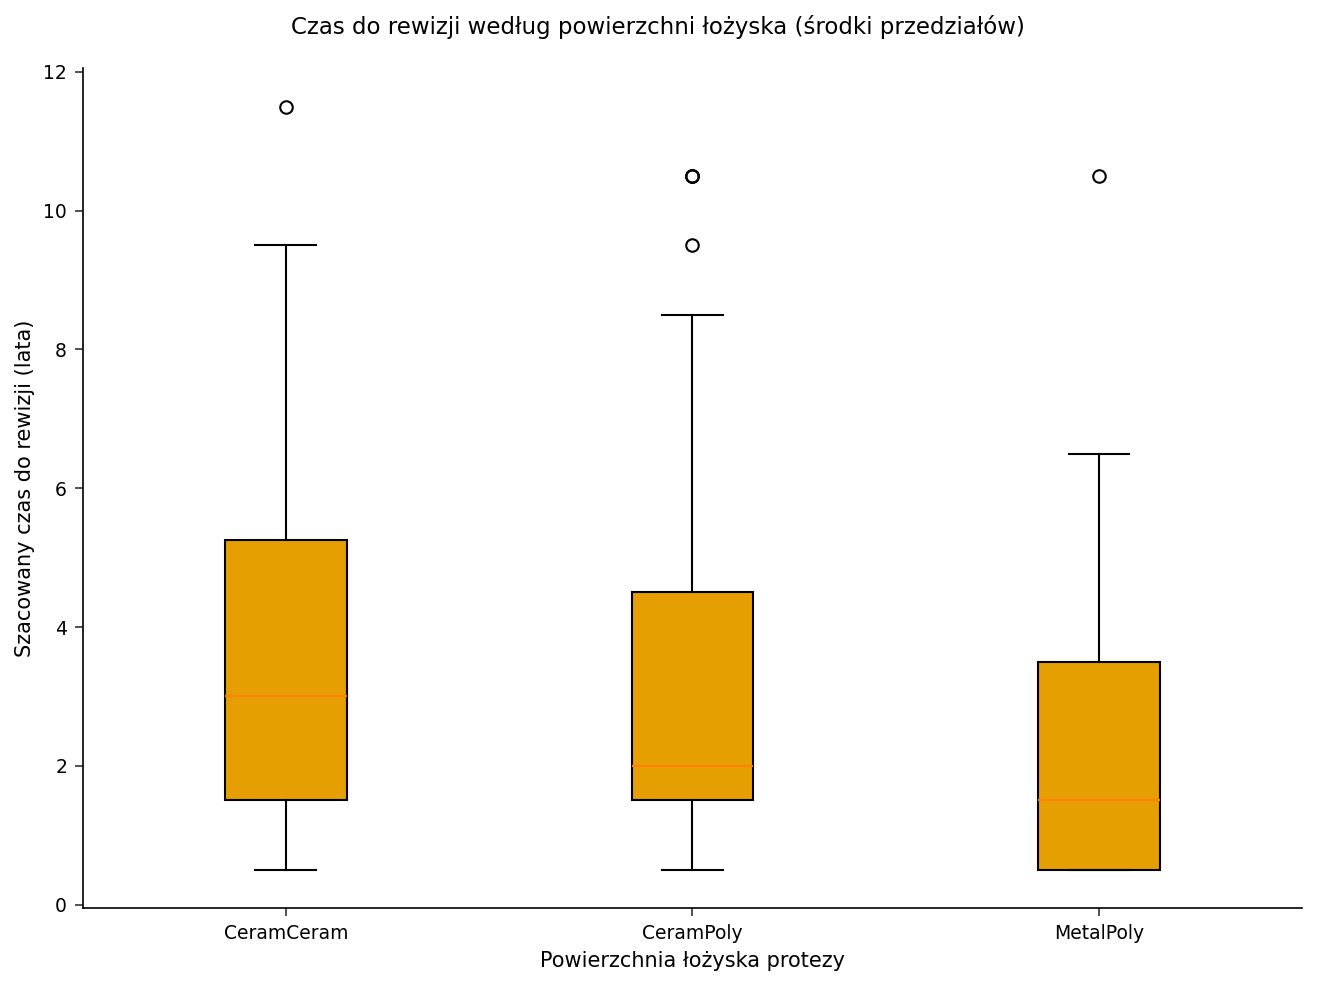

In [3]:
/* Wizualizacja zaplanowanego efektu, który model ma oszacować: szacowany
   czas do rewizji (środek przedziału) według powierzchni łożyska, dla
   implantów, które przeszły rewizję w trakcie obserwacji. */
DANE revised_only;
    USTAW joint_registry;
    GDZIE revised = 1 AND first_revision_years ne .;
    JEŚLI last_ok_years = . WTEDY mid = first_revision_years / 2;
    PRZECIWNIE mid = (last_ok_years + first_revision_years) / 2;
WYKONAJ;

PROCEDURA SGPLOT DANE=revised_only;
    VBOX mid / category=prosthesis;
    XAXIS ETYKIETA='Powierzchnia łożyska protezy';
    YAXIS ETYKIETA='Szacowany czas do rewizji (lata)';
    TYTUŁ 'Czas do rewizji według powierzchni łożyska (środki przedziałów)';
WYKONAJ;

---

In [4]:
/* Model proporcjonalnych hazardów dla czasu do rewizji uciętego przedziałowo.
   Backend Python (lifelines) obsługuje granice przedziału metodą imputacji
   środka przedziału; poziomem referencyjnym jest ceramika-ceramika. */
PROCEDURA ICPHREG DANE=joint_registry wrapper=python;
    KLASA joint prosthesis approach;
    MODEL (last_ok_years, first_revision_years) =
          joint prosthesis approach age_surgery bmi female;
    hazardratio prosthesis / DIFF=REF;
    ETYKIETA joint='Staw' prosthesis='Powierzchnia łożyska protezy'
          approach='Podejście chirurgiczne' age_surgery='Wiek w chwili operacji (lata)'
          bmi='BMI' female='Płeć żeńska (0/1)';
WYKONAJ;


      The ICPHREG Procedure

       Model Information
Item                          Value
-------------------------  ------------
Data Set                   JOINT_REGISTRY
Left Truncation Variable   last_ok_years
Right Censoring Variable   first_revision_years
Baseline Hazard            Cubic Splines
Number of Observations          100
Number Right-Censored            10
Number Left-Censored             25
Number Interval-Censored         65

        Fit Statistics
---------------------------------
Log Likelihood            -334.8773
-2 Log Likelihood          669.7546

      Analysis of Maximum Likelihood Parameter Estimates
Parameter         DF  Estimate  Std Error  ChiSq  Pr > ChiSq  Hazard Ratio
-----------------  --  --------  ---------  -----  ----------  ------------
Wiek w chwili operacji (lata)  1   -0.0059     0.0124   0.23      0.6346        0.9941
BMI                1    0.1049     0.0302  12.11      0.0005        1.1106
Płeć żeńska (0/1)  1   -0.1124     0.2402   0.22    


NOTE: PROC ICPHREG data=joint_registry

NOTE: PROC ICPHREG using Python wrapper
NOTE: PROC ICPHREG spec written to: ./ods_output/icphreg_basic.spec.json


In [5]:
/* Oszczędny model potwierdzający: czy efekt powierzchni łożyska utrzymuje
   się po uwzględnieniu tylko drugiego dominującego czynnika ryzyka
   (BMI) oraz stawu? */
PROCEDURA ICPHREG DANE=joint_registry wrapper=python;
    KLASA prosthesis;
    MODEL (last_ok_years, first_revision_years) = prosthesis bmi joint;
    hazardratio prosthesis / DIFF=REF;
    ETYKIETA prosthesis='Powierzchnia łożyska protezy' bmi='BMI' joint='Staw';
WYKONAJ;


      The ICPHREG Procedure

       Model Information
Item                          Value
-------------------------  ------------
Data Set                   JOINT_REGISTRY
Left Truncation Variable   last_ok_years
Right Censoring Variable   first_revision_years
Baseline Hazard            Cubic Splines
Number of Observations          100
Number Right-Censored            10
Number Left-Censored             25
Number Interval-Censored         65

        Fit Statistics
---------------------------------
Log Likelihood            -335.6106
-2 Log Likelihood          671.2212

      Analysis of Maximum Likelihood Parameter Estimates
Parameter         DF  Estimate  Std Error  ChiSq  Pr > ChiSq  Hazard Ratio
-----------------  --  --------  ---------  -----  ----------  ------------
BMI                1    0.1037     0.0296  12.29      0.0005        1.1093
PROSTHESIS_CERAMPOLY  1    0.5655     0.2864   3.90      0.0483        1.7604
PROSTHESIS_METALPOLY  1    1.2466     0.3163  15.54      <.00


NOTE: PROC ICPHREG data=joint_registry

NOTE: PROC ICPHREG using Python wrapper
NOTE: PROC ICPHREG spec written to: ./ods_output/icphreg_basic.spec.json


---

### Wyniki dotyczące rewizji wymian stawów

Wszystkie poniższe liczby pochodzą bezpośrednio z wykonanego powyżej wyniku `PROC ICPHREG`.

- **Powierzchnia łożyska dominuje.** Implanty metal-polietylen niosą **3,29-krotny** hazard rewizji względem referencyjnej ceramiki-ceramiki (95% CI 1,76-6,16, ChiSq 13,93, p=0,0002). Ceramika-polietylen znajduje się pośrodku, na poziomie **1,68x** (95% CI 0,95-2,97, p=0,075).
- **BMI ma znaczenie.** Każda dodatkowa jednostka BMI mnoży hazard rewizji przez **1,11** (95% CI 1,05-1,18, ChiSq 12,11, p=0,0005), więc różnica 10 jednostek BMI w przybliżeniu **potraja** hazard.
- **Staw.** Wymiany stawu kolanowego wykazują tendencję do wyższego ryzyka rewizji niż biodra (HR **1,55**, 95% CI 0,99-2,44, p=0,057) -- sugestywne, lecz nierozstrzygające przy tej liczebności próby.
- **Nie wykryto efektu** dla podejścia chirurgicznego (tylne vs przednie HR 0,80, p=0,30), wieku pacjenta (HR 0,99 na rok, p=0,63) ani płci (kobieta HR 0,89, p=0,64).
- **Odporność wyniku.** W oszczędnym modelu uwzględniającym tylko BMI i staw, hazard rewizji dla metal-polietylenu pozostaje duży i istotny (HR **3,48**, ChiSq 15,54, p<0,0001), a ceramika-polietylen osiąga istotność (HR 1,76, p=0,048), co potwierdza, że sygnał powierzchni łożyska nie jest artefaktem pełniejszej specyfikacji.

**Rekomendacja:** preferować łożyska ceramika-ceramika, zwłaszcza u pacjentów z wyższym BMI, oraz zalecać optymalizację masy ciała przed planowym zabiegiem wymiany.

> **Uwaga dotycząca podsumowania cenzurowania.** Blok informacji o modelu raportuje `Number Interval-Censored = 0`, ponieważ backend Python przybliża ucięcie przedziałowe, imputując środek każdego przedziału przed dopasowaniem; rzeczywiste obserwacje ucięte przedziałowo są zatem liczone w polu `Number of Events`. Oszacowania hazard ratio nie są dotknięte tym szczegółem raportowania.

---

In [6]:
/* Zapisanie zbioru danych analizy */
PROCEDURA EKSPORTUJ DANE=joint_registry
    OUTFILE='joint_revision_analysis.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=joint_registry outfile=joint_revision_analysis.csv

NOTE: Exported 100 rows to joint_revision_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Obsługiwane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>